## Analyse gridded contrail forcing simulations based on CoCiP for 2019

**Goal:** Evaluate **gridded forcing** from a newer 2019 simulation re-run by ICL with an updated version of pycontrails (v0.54.8). It has ~20% lower total energy forcing than the original publication and does not account for vPM activations. 

**Analyses:**

* File availability and statistics of forcing datasets
    - I used to approaches to analyse the data
        1. Convert tabular parquet files to hourly grid-based netcdf files + sum hourly grid-based files to get hourly, monthly and annual averages
        2. Directly sum parquet files for different FIRs to get hourly, monthly and annual statistics by FIR  - this method retains more of the original data fields since it is more memory efficient. At the same time, I lose all spatial information. 
    - Both approaches agree numerically
* Maps of flight distance, warming and contrails per flight
    - Use netcdf files and aggregate using xarray
* Forcing per **flight distance**, **hour**, **month**, **flight level**, and **FIR**
    - User parquet files with the exception of forcing per flight level
    - Aggregate using pandas


## 0. Data availability

In [ ]:
import os
import pandas as pd
from datetime import datetime

# --- CONFIG ---
# Path to your folder containing .pq files
FOLDER_PATH = "./"
# Path to the output CSV
OUTPUT_CSV = "forcing_pq_file_availability.csv"

# --- MAIN SCRIPT ---
data = []

# List all files in the directory
for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".pq"):
        filepath = os.path.join(FOLDER_PATH, filename)
        # Extract date from filename (assuming format YYYYMMDD.pq)
        try:
            date_str = filename.replace(".pq", "")
            date = datetime.strptime(date_str, "%Y%m%d").date()
        except ValueError:
            # Skip any files not matching the pattern
            continue
        
        availability = os.path.exists(filepath)
        data.append({
            "filename": filename,
            "date": date,
            "availability": availability
        })

# Convert to DataFrame
df = pd.DataFrame(data)

# Sort by date
df = df.sort_values(by="date")

# Save to CSV
df.to_csv(OUTPUT_CSV, index=False)

print(f"CSV written to {OUTPUT_CSV} with {len(df)} entries.")


![image.png](figures\2_forcing\forcing_1_pq_file_availability@2x.png)

## 1. Approach 1: Convert parquet files to netcdf and then sum

### Convert parquet to netcdf

- Adapt convert_parquet_to_netcdf.py to gridded forcing data and only keep fields relevant for this analysis
- Convert to 4 byte floating point numbers to save memory - this entails a loss of accuracy that I deem acceptable for this type of analysis

In [ ]:
"""
Convert contrail parquet data to hourly NetCDF (4D: lon-lat-alt-time).
"""

import warnings
import numpy as np
import pandas as pd
import xarray as xr
import sys
from tqdm import tqdm
import os 

# ----------- USER INPUTS ----------- #

FOLDER_PATH = "./"        # Folder with daily parquet files
OUTPUT_PATH = "cdf/"      # Folder to save hourly netcdf files

# CLI arguments: start and end date (inclusive)
if len(sys.argv) >= 3:
    DATE_START = sys.argv[1]
    DATE_END = sys.argv[2]
else:
    print("Usage: python script.py YYYY-MM-DD YYYY-MM-DD")
    sys.exit(1)

TEMPORAL_RES_H = 1  # 1-hour resolution

# Altitude dimension (m)
ALTITUDE_BOUNDS_M = (6000.0, 15000.0)
ALTITUDE_RES_M = 304.8 # 1000 ft = 10 flight levels

# Longitude-latitude dimension (degrees)
SPATIAL_BBOX = (-180.0, -90.0, 180.0, 90.0)
SPATIAL_GRID_RES = 0.25

# ----------- FUNCTIONS ----------- #

def _agg_to_grid(df_res, agg_map, lon_coords, lat_coords, alt_coords):
    shape = lon_coords.size, lat_coords.size, alt_coords.size

    # Perform a binary search on a sorted array a to find the indices where elements of v should be inserted to maintain the order of a.
    idx_lon = np.searchsorted(lon_coords, df_res["longitude"])
    idx_lat = np.searchsorted(lat_coords, df_res["latitude"])
    idx_alt = np.searchsorted(alt_coords, df_res["altitude"])

    # This gives an edge-centered grid!
    # If your longitude grid coordinates are: lon_coords = [0.0, 0.25, 0.50, 0.75, 1.0]
    # And your data points have longitudes: df_res["longitude"] = [0.1, 0.5, 0.99, 1.2]
    # idx_lon = np.searchsorted(lon_coords, df_res["longitude"]) would return: [1, 2, 4, 5]
    # Groupby the returned indices
    # So, lon = 0.25 will contain all longitudes from (0, 0.25]
    # This is actually slightly different from the standard xarray definition. 

    df_agg = df_res.groupby([idx_lon, idx_lat, idx_alt]).agg(agg_map)
    i0, i1, i2 = df_agg.index.get_level_values(0), df_agg.index.get_level_values(1), df_agg.index.get_level_values(2)
    ds = xr.Dataset(coords={"longitude": lon_coords, "latitude": lat_coords, "altitude": alt_coords})

    for name, col in df_agg.items():
        arr = np.zeros(shape, dtype=np.float32)
        arr[i0, i1, i2] = col.astype(np.float32)
        ds[name] = (("longitude", "latitude", "altitude"), arr)

    return ds


def _convert_daily_to_hourly(date: pd.Timestamp):
    date_str = date.strftime("%Y%m%d")
    file_path = f"{FOLDER_PATH}/{date_str}.pq"
    df_res = pd.read_parquet(file_path)

    # Downcast floats
    float_cols = df_res.select_dtypes(include=['float64']).columns
    df_res[float_cols] = df_res[float_cols].astype('float32')

    df_res['new_contrail_length'] = df_res['new_contrail_length'].fillna(0)

    # Filter by spatial and altitude bounds
    west, south, east, north = SPATIAL_BBOX
    df_res = df_res[
        df_res["longitude"].between(west, east)
        & df_res["latitude"].between(south, north)
        & df_res["altitude"].between(*ALTITUDE_BOUNDS_M)
    ].copy()

    # Coordinates
    lon_coords = np.arange(west, east + 0.01, SPATIAL_GRID_RES)
    lat_coords = np.arange(south, north + 0.01, SPATIAL_GRID_RES)
    alt_coords = np.arange(ALTITUDE_BOUNDS_M[0], ALTITUDE_BOUNDS_M[1] + ALTITUDE_RES_M, ALTITUDE_RES_M)
    df_res["hour"] = df_res["hour"].round().astype(int)

    # Time slices
    time_slices = np.arange(0, 25, TEMPORAL_RES_H)
    for t in range(len(time_slices) - 1):
        h_start, h_end = time_slices[t], time_slices[t + 1]
        filt = df_res["hour"].between(h_start, h_end, inclusive="left")
        df_hour = df_res[filt].copy()
        if len(df_hour) == 0:
            continue
        _grid_one_hour(date, h_start, h_end, df_hour, lon_coords, lat_coords, alt_coords)


def _grid_one_hour(date, h_start, h_end, df_hour, lon_coords, lat_coords, alt_coords):

    # Build expected output filename early
    t_start_str = date.strftime("%Y%m%d")
    t_end_str = f"{h_end:02d}"
    output_file = f"{OUTPUT_PATH}/{t_start_str}-{h_start:02d}-{t_end_str}-contrail.nc"

    # Aggregations
    agg_map = {
        'total_flight_dist': 'sum',
        'contrail_ef_overlap_initial_loc': 'sum',
    }
    ds_agg = _agg_to_grid(df_hour, agg_map, lon_coords, lat_coords, alt_coords)

    # Merge hourly datasets
    ds = xr.Dataset(
        data_vars=dict(
            total_flight_dist=(["longitude", "latitude", "altitude"], ds_agg["total_flight_dist"].values / 1000),
            ef_initial_loc_overlap=(["longitude", "latitude", "altitude"], ds_agg["contrail_ef_overlap_initial_loc"].values),
        ),
        coords=dict(longitude=lon_coords, latitude=lat_coords, altitude=alt_coords)
    )

    # Add time dimension
    t_mid = date + pd.Timedelta(hours=h_start + TEMPORAL_RES_H / 2)
    ds = ds.expand_dims().assign_coords({"time": t_mid})

    # Compression and saving
    t_start_str = date.strftime("%Y%m%d")
    t_end_str = f"{h_end:02d}"
    output_file = f"{OUTPUT_PATH}/{t_start_str}-{h_start:02d}-{t_end_str}-contrail.nc"


    comp = dict(zlib=True, complevel=4, dtype='float32')
    encoding = {var: comp for var in ds.data_vars}
    ds.to_netcdf(output_file, encoding=encoding)
    print(f"✅ Saved {output_file}")


def main():
    dates = pd.date_range(DATE_START, DATE_END, freq="1D")
    for date in tqdm(dates, desc="Processing days"):
        _convert_daily_to_hourly(date)


if __name__ == "__main__":
    main()


### Check conversion of netcdf files
I am checking this since the netcdf file writer often fails (writes files only containing zeros) and I needed to run it several times for all files to be written correctly (hopefully). 


In [ ]:
import os
import re
import pandas as pd
from datetime import datetime

# --- CONFIG ---
FOLDER_PATH = "/path/to/your/cdf/folder"
OUTPUT_CSV = "daily_nc_availability.csv"

# --- MAIN SCRIPT ---
pattern = re.compile(r"(\d{8})-(\d{2})-(\d{2})-contrail\.nc$")

# Dictionary to store available hours per day
# If we have all the hourly info, the end result should be a dict with 365 entries and 24 elements in the set for each entry.
availability = {}

for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".nc"):
        match = pattern.search(filename)
        if not match:
            continue

        date_str, hour_start, _ = match.groups()
        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Record availability for that hour
        # Set empty default set for each date and then add hours
        availability.setdefault(date, set()).add(int(hour_start))

# Build a list of rows for the CSV
rows = []
for date, hours in sorted(availability.items()):
    total_hours_available = len(hours)
    share = total_hours_available / 24  # Share of day covered
    rows.append({
        "date": date,
        "filename_pattern": f"{date.strftime('%Y%m%d')}-*-*-contrail.nc",
        "availability_share": round(share, 3)
    })

# Convert to DataFrame and save
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Wrote {OUTPUT_CSV} with {len(df)} days of data.")


![image.png](figures\2_forcing\forcing_2_netcdf_file_availability@2x.png)

### Sum netcdf files
- sum all numerical variables in netcdf input files and write to outfile with compression
- make sure that grids coincide

In [ ]:
import sys
import xarray as xr
import os

OUTFILE = sys.argv[1]
FILES = sys.argv[2:]

def aggregate(files, outfile):
    running_sum = None
    for f in files:
        try:
            ds = xr.open_dataset(f, engine="netcdf4", decode_timedelta=False)
            print(f"Processing {f} with vars: {ds.data_vars}")
            ds = ds.fillna(0).squeeze(drop=True)
            ds = ds.drop_vars("hour", errors="ignore")
            if running_sum is None:
                running_sum = ds.astype("float32")
            else:
                running_sum = running_sum + ds.astype("float32")
        except Exception as e:
            print(f"⚠️ Error reading {f}: {e}")
        finally:
             ds.close()

    if running_sum is not None:
        encoding = {
            var: {"zlib": True, "complevel": 4, "dtype": "float32"}
            for var in running_sum.data_vars
        }
        running_sum.to_netcdf(outfile, encoding=encoding)
        print(f"✅ Saved {outfile}")

if __name__ == "__main__":
    if not FILES:
        print("No files given.")
        sys.exit(1)
    aggregate(FILES, OUTFILE)


### Run multi-threated summation of netcdf files

- read hourly netcdf files for the entire year and sum them by hour, month and finally year

In [ ]:
#!/usr/bin/env python3
import os
import subprocess
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

# ================= CONFIG ==================
INDIR = "cdf/"
OUTDIR = "aggregated"
os.makedirs(OUTDIR, exist_ok=True)
N_WORKERS = 12  # Adjust for your CPU / cluster
# ===========================================

def parse_time(fname):
    """Parse filenames like 20190101-11-12-gaia.nc -> datetime(2019,1,1,11)."""
    base = os.path.basename(fname).replace(".nc", "")
    parts = base.split("-")
    if len(parts) >= 4 and parts[-1] == "contrail":
        date_str = parts[0]  # 20190101
        hour_str = parts[1]  # 11 (start hour)
        dt = datetime.strptime(f"{date_str}{hour_str}", "%Y%m%d%H")
        return dt
    raise ValueError(f"Unexpected filename format: {fname}")

def call_worker(outpath, files):
    """Run the external aggregation script."""
    if not files:
        print(f"⚠️ No input files for {outpath}, skipping.")
        return None
    
    try:
        subprocess.run(
            ["python", "aggregate.py", outpath] + files,
            check=True
        )
        return outpath
    except subprocess.CalledProcessError as e:
        print(f"❌ Failed to aggregate {outpath}: {e}")
        return None

def launch_parallel_aggregate(jobs, desc):
    """
    Run a batch of call_worker tasks in parallel.
    jobs: list of tuples (outpath, files)
    desc: str, description for logging
    Returns: list of successful outpaths
    """
    results = []
    if not jobs:
        print(f"⚠️ No jobs to run for {desc}.")
        return results

    print(f"🚀 Launching {len(jobs)} {desc} jobs using {N_WORKERS} workers...")
    #for out, flist in jobs:
    #    call_worker(out, flist)
    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        future_map = {executor.submit(call_worker, out, flist): out for out, flist in jobs}
        for fut in as_completed(future_map):
            outpath = future_map[fut]
            res = fut.result()
            if res:
                results.append(res)
                print(f"✅ Done: {os.path.basename(outpath)}")
            else:
                print(f"⚠️ Skipped or failed: {os.path.basename(outpath)}")
    print(f"✅ Completed all {desc} jobs.\n")
    return results

def main():
    # === STEP 1: Gather input files ===
    nc_files = sorted([
        os.path.join(INDIR, f)
        for f in os.listdir(INDIR)
        if f.endswith(".nc") and "-contrail" in f
    ])
    print(f"📦 Found {len(nc_files)} input files.")

    print("Processing hourly sums per month")
    # === STEP 2: Hourly sums per month ===
    hourly_jobs = []
    for month in range(1, 13):
        for hour in range(0, 24):
            files = [f for f in nc_files if parse_time(f).month == month and parse_time(f).hour == hour]
            if not files:
                continue
            outname = f"hourly_sum_m{month:02d}_h{hour:02d}.nc"
            outpath = os.path.join(OUTDIR, outname)
            hourly_jobs.append((outpath, files))

    print(f"Calling launch_parallel_aggregate with {len(hourly_jobs)}")
    hourly_by_month_files = {}
    hourly_results =  [outpath for outpath, _ in hourly_jobs]# launch_parallel_aggregate(hourly_jobs, "hourly (month-hour)") #
    for outpath in hourly_results:
        name = os.path.basename(outpath)
        parts = name.replace("hourly_sum_m", "").replace(".nc", "").split("_h")
        month = int(parts[0])
        hour = int(parts[1])
        hourly_by_month_files[(month, hour)] = outpath

    print("Computing monthly sums!")

    # === STEP 3: Monthly sums ===
    monthly_jobs = []
    for month in range(1, 13):
        files = [hourly_by_month_files[(month, h)] for h in range(24) if (month, h) in hourly_by_month_files]
        if not files:
            continue
        outname = f"monthly_sum_{month:02d}.nc"
        outpath = os.path.join(OUTDIR, outname)
        monthly_jobs.append((outpath, files))

    monthly_results = launch_parallel_aggregate(monthly_jobs, "monthly")
    monthly_files = {int(os.path.basename(f).split("_")[2].split(".")[0]): f for f in monthly_results}


    # === STEP 4: Annual sum ===
    if monthly_files:
        annual_out = os.path.join(OUTDIR, "annual_sum.nc")
        print(f"→ Aggregating annual sum from {len(monthly_files)} monthly files...")
        call_worker(annual_out, list(monthly_files.values()))
    else:
        print("⚠️ Skipping annual sum — no monthly files found.")


    # === STEP 5: Hourly sums across all months ===
    hourly_across_jobs = []
    for hour in range(0, 24):
        files = [hourly_by_month_files[(m, hour)] for m in range(1, 13) if (m, hour) in hourly_by_month_files]
        if not files:
            continue
        outname = f"annual_hourly_sum_{hour:02d}.nc"
        outpath = os.path.join(OUTDIR, outname)
        hourly_across_jobs.append((outpath, files))

    launch_parallel_aggregate(hourly_across_jobs, "hourly-across-months")

    print("🎉 All aggregations complete.")

if __name__ == "__main__":
    main()

## 2. Approach 2: Compute statistics directly from parquet files

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import regionmask
import json, topojson
import glob, re
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import datetime

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
COLS_SUM = [
    "total_flight_dist", 
    "contrail_ef_initial_loc",
    "contrail_ef_overlap_initial_loc", 
    "new_contrail_length", 
    "total_contrail_length", 
    "tau_contrail_area", 
    "mean_contrail_age", 
    "contrail_ef", 
    "contrail_ef_sw", 
    "contrail_ef_lw", 
    "contrail_ef_overlap", 
    "contrail_ef_sw_overlap", 
    "contrail_ef_lw_overlap"
]


def build_regionmask():
    """Builds a combined regionmask from FIRs."""

    
    # Load the combined GeoDataFrame
    gdf_combined = gpd.read_file("airspaces.geojson").set_crs(epsg=4326)

    # Build the region mask
    combined_mask = regionmask.Regions(
        outlines=gdf_combined.geometry.values,
        names=gdf_combined["name"].tolist(),
        abbrevs=gdf_combined["name"].tolist()
    )

    return combined_mask


def process_file(file, mask):
    """Processes a single parquet file for all FIR/regions."""
    import pandas as pd
    import geopandas as gpd
    from shapely.geometry import Point
    import re

    fname = Path(file).stem
    m = re.search(r"(\d{8})", fname)
    date = pd.Timestamp(m.group(1)) if m else pd.NaT

    df = pd.read_parquet(file).fillna(0)
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326")

    results = []
    for region_id, region_name in enumerate(mask.names):
        print("Processing: ", region_name)
        geom = mask[region_id].polygon
        minx, miny, maxx, maxy = geom.bounds
        subset = gdf.cx[minx:maxx, miny:maxy]
        subset = subset[subset.geometry.within(geom)]
        if subset.empty:
            continue

        df_hourly = subset.groupby("hour")[COLS_SUM].sum(min_count=1).reset_index()
        df_hourly["timestamp"] = [date + pd.Timedelta(hours=int(h)) for h in df_hourly["hour"]]
        df_hourly["region"] = region_name
        df_hourly["file"] = Path(file).name
        results.append(df_hourly)

    return pd.concat(results, ignore_index=True) if results else None


def main():
    """Main entry point for multiprocessing FIR analysis."""
    folder_path = "./"
    pq_files = sorted(glob.glob(f"{folder_path}/*.pq"))

    n_workers = 4  # Adjust to CPU cores

    if not pq_files:
        print("❌ No parquet files found!")
        return

    print(f"Found {len(pq_files)} parquet files")
    mask = build_regionmask()

    results = []
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(process_file, f, mask): f for f in pq_files}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Processing files"):
            try:
                df_res = fut.result()
                if df_res is not None:
                    results.append(df_res)
            except Exception as e:
                print(f"⚠️ Error processing {futures[fut]}: {e}")

    if not results:
        print("❌ No data processed!")
        return

    df_all = pd.concat(results, ignore_index=True)
    output_path = Path("hourly_totals_by_region.pq")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_parquet(output_path, index=False)
    print(f"✅ Multiprocessing complete. Results saved to {output_path}")


if __name__ == "__main__":
    main()


## 3. Global statistics (used in report)

Compute forcing statistics and compare with results in Teoh et al. 2024 to check whether the conversions/summations went well. 

### Compute statistics using the netcdf approach 1

In [1]:
import xarray as xr 
import pandas as pd 
ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")

In [5]:
import xarray as xr 
import pandas as pd 
ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")
ds["forcing_per_dist"] = ds["ef_initial_loc_overlap"] / ds["total_flight_dist"]



# These definitions follow the bounding boxes in Teoh et al.'s paper (except for Eurocontrol)
regions = {
    "Global": {"lon_min": -180, "lon_max": 180, "lat_min": -90, "lat_max": 90},
    "USA": {"lon_min": -126, "lon_max": -66, "lat_min": 23, "lat_max": 50},
    "Europe": {"lon_min": -12, "lon_max": 20, "lat_min": 35, "lat_max": 60},
    "Eurocontrol": {"lon_min": -30.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "Eurocontrol + North Atlantic": {"lon_min": -70.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "East_Asia": {"lon_min": 103, "lon_max": 150, "lat_min": 15, "lat_max": 48},
    "Southeast_Asia": {"lon_min": 87.5, "lon_max": 130, "lat_min": -10, "lat_max": 20},
    "Latin_America": {"lon_min": -85, "lon_max": -35, "lat_min": -60, "lat_max": 15},
    "Africa_Middle_East": {"lon_min": -20, "lon_max": 50, "lat_min": -35, "lat_max": 40},
    "China": {"lon_min": 73.5, "lon_max": 135, "lat_min": 18, "lat_max": 53.5},
    "India": {"lon_min": 68, "lon_max": 97.5, "lat_min": 8, "lat_max": 35.5},
    "North Atlantic": {"lon_min": -70, "lon_max": -5, "lat_min": 40, "lat_max": 63},
    "North Pacific": {"lon_min": 140, "lon_max": -120, "lat_min": 35, "lat_max": 65},
    "Arctic": {"lon_min": -180, "lon_max": 180, "lat_min": 66.5, "lat_max": 90}, 
}

def subset_region(ds, region):
    """Return subset of dataset within the region bounding box."""
    lon_min, lon_max = region["lon_min"], region["lon_max"]
    lat_min, lat_max = region["lat_min"], region["lat_max"]

    # Handle longitude wrap-around (e.g. North Pacific)
    if lon_min < lon_max:
        subset = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    else:
        # For regions crossing the dateline (e.g. 140E–120W)
        subset1 = ds.sel(longitude=slice(lon_min, 180))
        subset2 = ds.sel(longitude=slice(-180, lon_max))
        subset = xr.concat([subset1, subset2], dim="longitude")
        subset = subset.sel(latitude=slice(lat_min, lat_max))
    
    return subset


regional_stats = {}

for name, bbox in regions.items():
    ds_region = subset_region(ds, bbox)
    stats = {
        "Energy forcing (x 10^18 J)": round(float(ds_region["ef_initial_loc_overlap"].sum().values)/1e18, 1),
        "Flight distance (x 10^9 km)": round(float(ds_region["total_flight_dist"].sum().values)/1e9, 1)
    }
    regional_stats[name] = stats

df = pd.DataFrame(regional_stats)
df.to_csv("output/forcing/3_statistics.csv")
df

,Global,USA,Europe,Eurocontrol,Eurocontrol + North Atlantic,East_Asia,Southeast_Asia,Latin_America,Africa_Middle_East,China,India,North Atlantic,North Pacific,Arctic
Energy forcing (x 10^18 J),778.7,143.0,140.9,293.3,361.5,24.9,42.3,21.1,32.8,32.3,12.7,99.9,39.4,9.8
Flight distance (x 10^9 km),52.6,13.2,7.4,13.2,15.2,7.3,3.5,1.9,4.3,7.9,2.3,3.0,2.1,0.4


### Statistics from Teoh et al. 2024

Comparing the statistics to the following table from the publication, I conclude that they seem to make sense. 

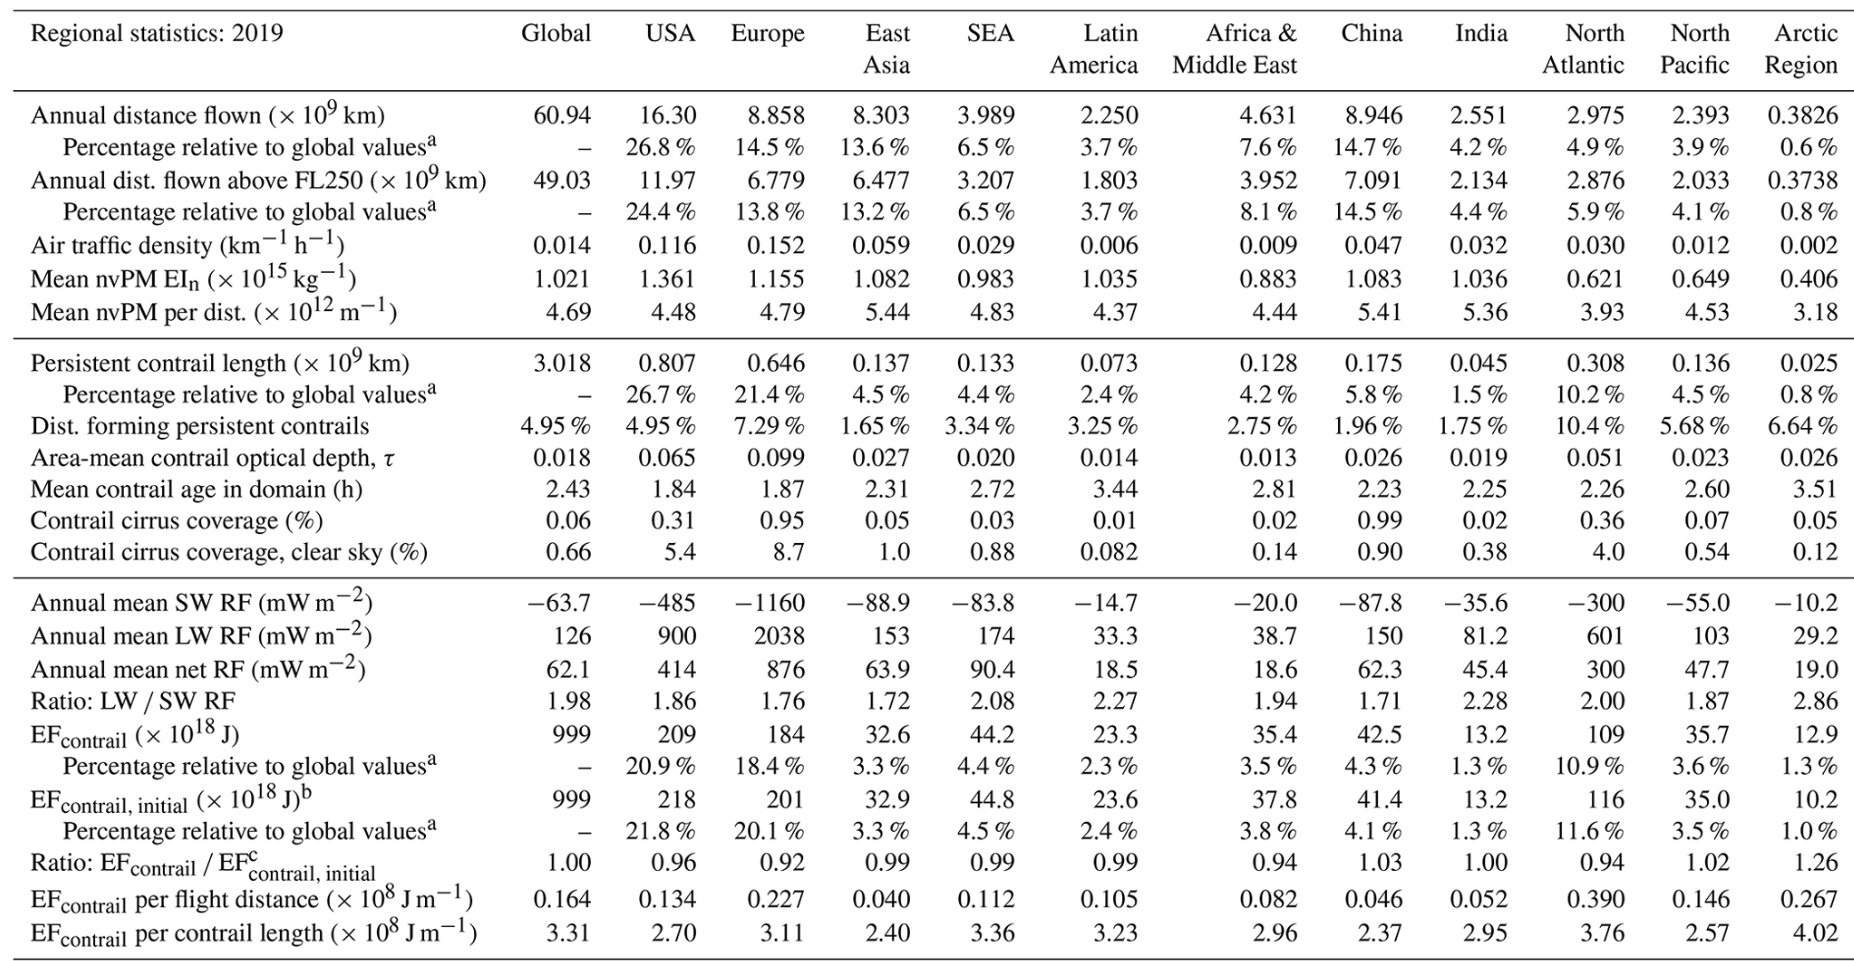

### Compute statistics using parquet approach 2

In [ ]:
import pandas as pd
import geopandas as gpd


# These hourly totals are obtained by directly summing the parquet files without the grid
# This should be less prone to bugs in the code than the above approach and give better results
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

df_region_sums = df.groupby("region").sum(numeric_only=True).reset_index()



# Load airspace geometry to get information about Eurocontrol airspaces back
airspaces = gpd.read_file("data/airspaces.geojson")
air_attr = airspaces[["name", "Eurocontrol FIR", "type"]]
df_merged = df_region_sums.merge(
    air_attr,
    how="left",
    left_on="region",
    right_on="name"
).drop(columns="name")


df_merged.to_csv("output/forcing/3_statistics.csv", index=False)


df_merged[df_merged["region"] == "Global"]

,region,hour,total_flight_dist,contrail_ef_initial_loc,contrail_ef_overlap_initial_loc,new_contrail_length,total_contrail_length,tau_contrail_area,mean_contrail_age,contrail_ef,contrail_ef_sw,contrail_ef_lw,contrail_ef_overlap,contrail_ef_sw_overlap,contrail_ef_lw_overlap,Eurocontrol FIR,type
87,Global,100740,6.085401e+13,8.294830e+20,7.716292e+20,3.227577e+12,1.148644e+13,1.127690e+16,1.539507e+09,8.298887e+20,-1.038676e+21,1.869836e+21,7.717040e+20,-9.690562e+20,1.749584e+21,None,RECT


### Do these results make sense? 

The netcdf method 1 gives 779e18 J and the parquet summation method 2 gives 772e18 J. After some in-depth testing, I believe that  there are disk errors when reading the parquet files. Sometimes, the daily or hourly files will just contain zeros. Anyway, the correct number is 779x10^18 J consistent between different experiments and Roger. There is a small mismatch between `hourly_totals_by_region.pq` and the correct value (probably a small number of files read incorrectly), but I deem it acceptable since the error is below 1% and there is no systematic trend (e.g. only Mondays missing) according to my tests. 

Do these results make sense? 
Roger Teoh wrote me the following: 
```
 These results are from a more recent (yet to be published) simulations using pycontrails v0.54.8 without vPM activation, and the contrail RF is around 20% lower than those in the publication. We have to share this more recent dataset, rather than the publication, because the gridded outputs have a much higher spatiotemporal resolution. 
```

2019 contrail RF is 779e18 J versus 999e18 J for 2019. This is roughly 20% lower and matches Roger's description.

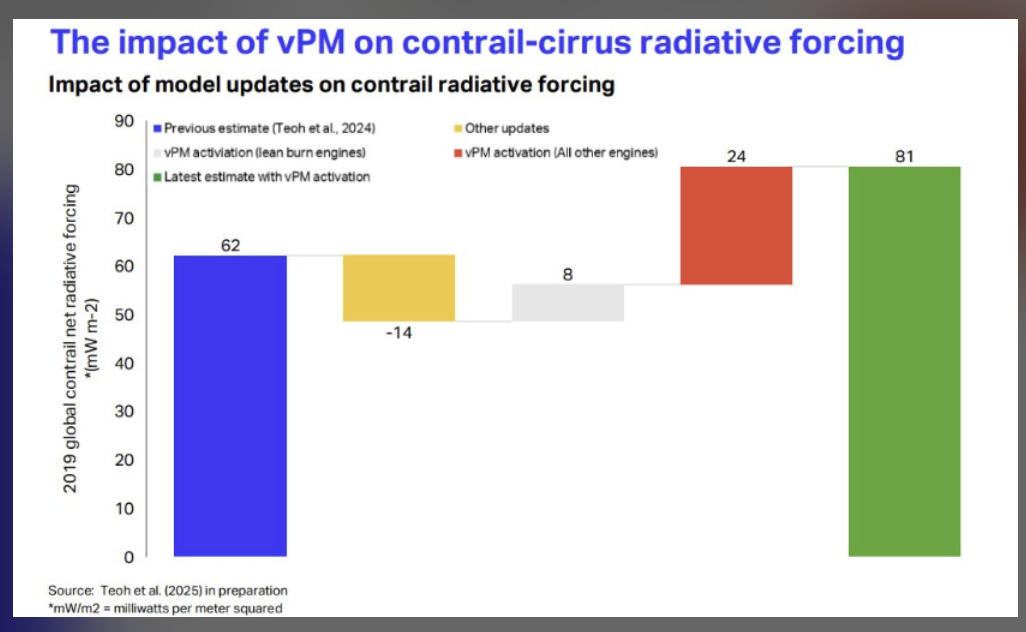

In [22]:
def joule_to_mW_per_m2(E):
    R = 6371                           # km, Earth average radius
    A = 4 * 3.1415 * R * R * 1e6       # Earth surface in m^2
    W = E / (365 * 24 * 60 * 60) * 1e3 # Annual radiation work in mW
    return W/A                         # forcing in mW/m^2 

f1 = joule_to_mW_per_m2(E = 999e18) # Annual energy forcing in J from Roger's publication
f2 = joule_to_mW_per_m2(E = 779e18) # Annual energy forcing in J from Roger's publication
f1, f2, f1-14                       # The 778e18 J figure closely matches this figure

(62.10786720404258, 48.43045901096013, 48.10786720404258)

## 4. European Maps (used in report)

In [4]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

OUTDIR = "aggregated"

def plot_map(ds, var="seg_length_km", title="", cbar_label = "", vmin=None, vmax=None, savepath=None):
    """
    Plot a 2D map of the given variable from an xarray Dataset.
    Assumes dimensions: (flight_level, latitude, longitude).
    Sums over flight levels before plotting.
    """
    # --- Sum over altitude / flight levels ---
    if var == "forcing_per_dist": 
        data_2d_forcing = ds["ef_initial_loc_overlap"].sum(dim="altitude").squeeze()
        data_2d_dist    = ds["total_flight_dist"     ].sum(dim="altitude").squeeze()
        data_2d         = xr.where(data_2d_dist != 0, data_2d_forcing / data_2d_dist, 0)
    else: 
        data_2d = ds[var].sum(dim="altitude").squeeze()

    # Replace zeros with NaN for clarity
    #data_2d = data_2d.where(data_2d != 0).values

    lon = ds.longitude.values
    lat = ds.latitude.values

    proj = ccrs.AlbersEqualArea(
        central_longitude=0,  # Center of map horizontally
        central_latitude=30,  # Center vertically
        standard_parallels=(20, 40)  # Choose parallels around your region of interest
    )

    # --- Setup map ---
    fig, ax = plt.subplots(
        subplot_kw={"projection": proj},
        figsize=(7.94*2, 5.75*2)
    )

    # Pick the right viewing window
    ax.set_extent([-70., 45.0, 25., 60.], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # --- Plot data ---
    im = ax.imshow(
        data_2d.T,  # transpose to match lon/lat orientation
        origin="lower",
        cmap="gist_heat_r",
        transform=ccrs.PlateCarree(),
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        vmin=vmin,
        vmax=vmax
    )   
    
    plt.axis('off')


    # --- Save to PNG ---
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", pad_inches=0)


    
    plt.show()

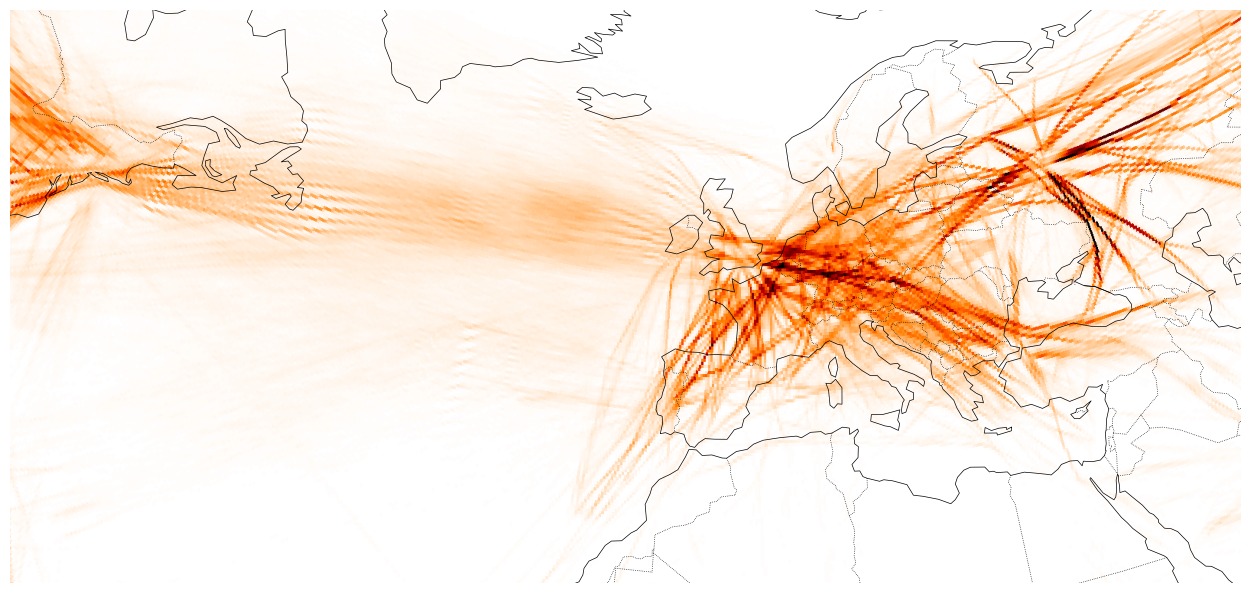

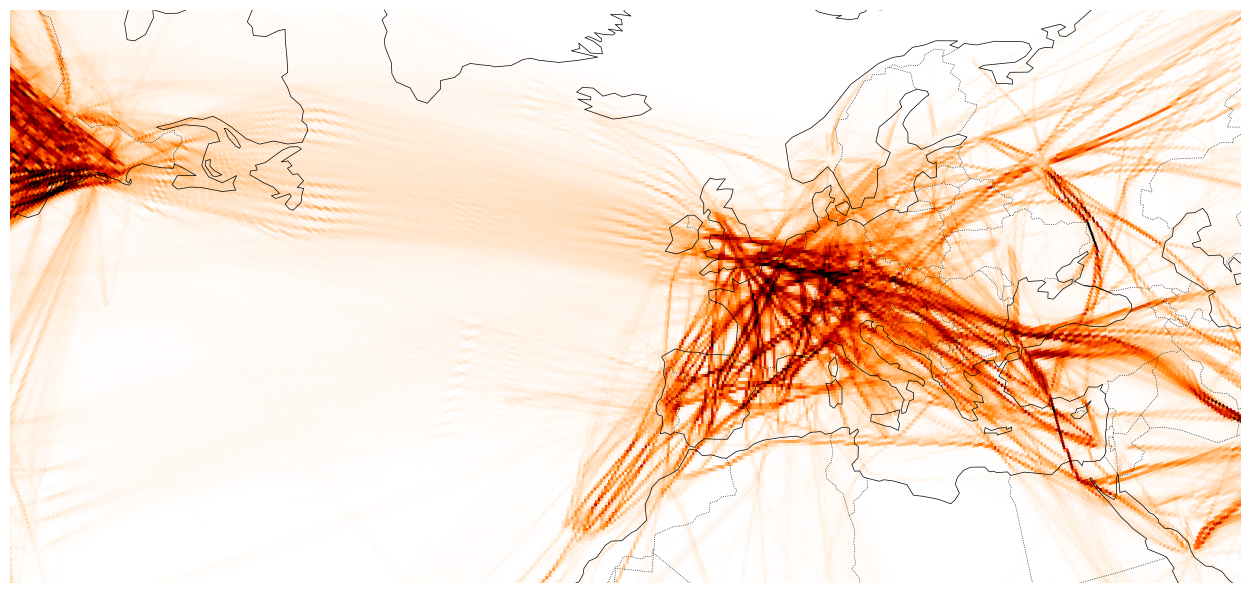

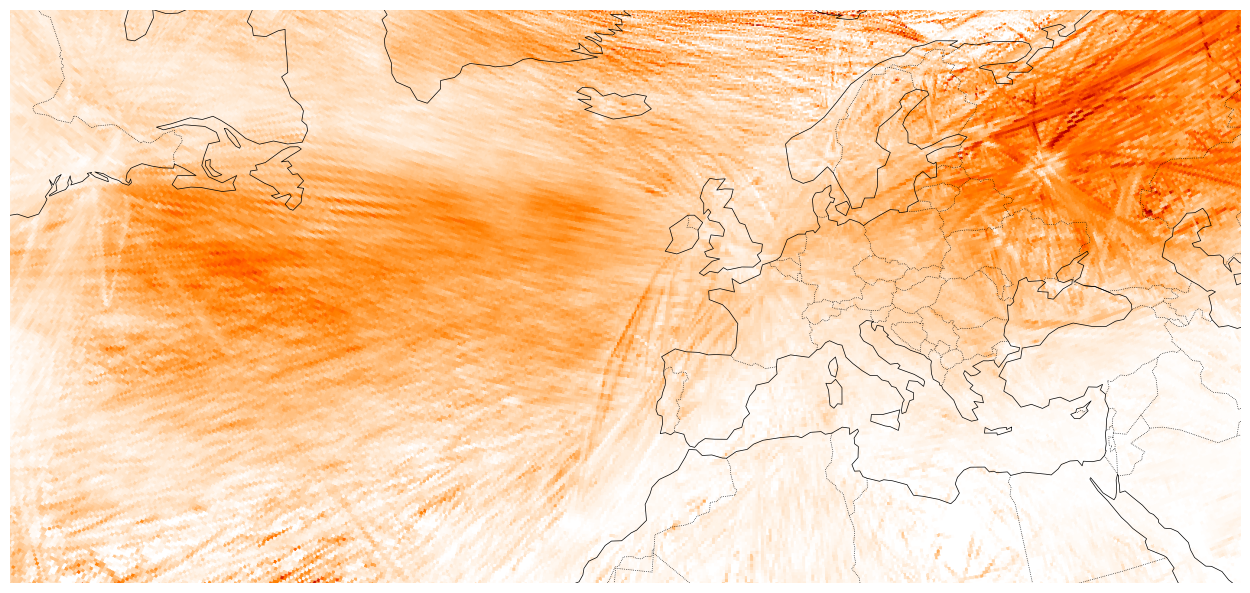

In [ ]:
import xarray as xr 
ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")

# Here I have a cutoff for flight dist and contrail warming since otherwise, a handful of points would dominate the colour scheme. 
plot_map(ds, var="ef_initial_loc_overlap", vmin=0,      vmax = 1e17, title="North Atlantic Contrail Warming",             cbar_label="Energy forcing in J", savepath="output/forcing/4_eurocontrol_warming_map.png")
plot_map(ds, var="total_flight_dist",      vmin=0,      vmax = 3e6,  title="North Atlantic Flight Distance",              cbar_label="Flight distance in km", savepath="output/forcing/4_eurocontrol_flight_distance_map.png")
plot_map(ds, var="forcing_per_dist",       vmin=0,                   title="Global Contrail Warming Per Flight Distance", cbar_label="Energy forcing per flight distance in J/m", savepath="output/forcing/4_eurocontrol_warming_per_flight_distance_map.png")

## 5. Traffic by flight level (used in report)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd#
import geopandas as gpd
import regionmask

def make_fl_bands(fl_step=10, fl_max=500):
    """
    Generate a dictionary of flight level bands in meters.

    Parameters
    ----------
    fl_step : int
        Step size in flight levels (hundreds of feet), e.g. 25 = 2500 ft.
    fl_max : int
        Maximum flight level (hundreds of feet), e.g. 500 = 50,000 ft.

    Returns
    -------
    dict
        Keys: band labels (e.g. 'FL000–025'), 
        Values: (lower_alt_m, upper_alt_m) tuples.
    """
    ft_to_m = 0.3048  # 1 ft = 0.3048 m
    fl_bands = {}
    for fl in range(0, fl_max, fl_step):

        label = f"FL{fl:03d}"
        fl_bands[label] = ((fl - fl_step/2)* 100 * ft_to_m, (fl + fl_step/2) * 100 * ft_to_m)
    return fl_bands

def aggregate_by_flight_level(ds, var="total_flight_dist"):
    # --- Define finer flight level bands (in meters) ---
    fl_bands = make_fl_bands()

    # --- Sum horizontally first ---
    var_sum = ds[var].sum(dim=["longitude", "latitude"])
    alt = ds["altitude"]

    # --- Aggregate per band ---
    var_agg = []
    labels = []

    for fl_label, (zmin, zmax) in fl_bands.items():
        mask = (alt >= zmin) & (alt < zmax)
        if mask.any():
            var_band = var_sum.where(mask, drop=True).sum()
            var_agg.append(var_band.item())
            labels.append(fl_label)

    return labels, np.array(var_agg)

def subset_region(ds, region_polygon):
    """
    Clip an xarray dataset to a region polygon.
    """
    mask = regionmask.Regions([region_polygon])
    
    # Apply masking
    mask_xr = mask.mask(ds["longitude"], ds["latitude"])

    # Region 0 → keep where mask_xr == 0
    return ds.where(mask_xr == 0, drop=True)

def aggregate_region(ds, region_name, region_polygon, var1="total_flight_dist", var2="ef_initial_loc_overlap"):
    """
    Subset a dataset to a region polygon and compute FL aggregates.
    Returns a dataframe with a 'region' column.
    """
    # subset grid
    ds_region = subset_region(ds, region_polygon)

    # aggregate
    fl, v1 = aggregate_by_flight_level(ds_region, var=var1)
    _,  v2 = aggregate_by_flight_level(ds_region, var=var2)

    # build output df
    df = pd.DataFrame({
        "Flight level":              fl,
        "Flight distance":           v1 / 1e9,
        "Contrail warming":          v2 / 1e18,
        "Warming per flight dist":   v2 / v1 / 1e9,
        "Region":                    region_name,
    })

    return df

ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")
ds = ds.drop_sel(longitude=180)

gdf_combined = gpd.read_file("data/airspaces.geojson").set_crs(epsg=4326)

combined_mask = regionmask.Regions(
    outlines=gdf_combined.geometry.values,
    names=gdf_combined["name"].tolist(),
    abbrevs=gdf_combined["name"].tolist(),
)


all_dfs = []

for rid, rname in enumerate(combined_mask.names):
    print(f"Processing region: {rname}")
    geom = combined_mask[rid].polygon
    df_reg = aggregate_region(ds, rname, geom)
    all_dfs.append(df_reg)

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.to_csv("output/forcing/5_forcing_by_flight_level.csv", index=False)
df_all


![image.png](figures\2_forcing\forcing_5_by_flight_level@2x.png)

## 6. Forcing by hour (used in report)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute hourly aggregates
df_hourly = (
    df
    .groupby(["region", df["timestamp"].dt.hour.rename("hour")], sort=False)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

df = pd.DataFrame({
    "Hour":                        df_hourly["hour"], 
    "Flight distance":             df_hourly["total_flight_dist"]/1e9, 
    "Contrail warming":            df_hourly["contrail_ef_overlap_initial_loc"]/1e18, 
    "Warming per flight distance": df_hourly["contrail_ef_overlap_initial_loc"]/df_hourly["total_flight_dist"]/1e6,
    "Region":                      df_hourly["region"]
    }).round(4)



# Sort each region block by shifted hour order, preserving overall region order
df = (
    df.groupby("Region", group_keys=False, sort=False)
      .apply(lambda g: g.sort_values("Hour", key=lambda x: (x - 6) % 24))
      .reset_index(drop=True)
)

# Save 
df.to_csv("output/forcing/6_forcing_by_hour.csv", index=False)

df

C:\Users\TE\AppData\Local\Temp\ipykernel_30236\3698629416.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("Hour", key=lambda x: (x - 6) % 24))


,Hour,Flight distance,Contrail warming,Warming per flight distance,Region
0,6,537.511597,2.6021,4.8410,European Airspace
1,7,669.345703,1.3301,1.9872,European Airspace
2,8,745.639587,0.4345,0.5827,European Airspace
3,9,798.182800,0.3947,0.4945,European Airspace
4,10,841.997009,1.0610,1.2601,European Airspace
...,...,...,...,...,...
6427,1,14.015500,-0.1896,-13.5270,Shenyang FIR
6428,2,15.381000,-0.1977,-12.8552,Shenyang FIR
6429,3,15.342300,-0.1570,-10.2332,Shenyang FIR
6430,4,16.363100,-0.1219,-7.4478,Shenyang FIR


![image.png](figures\2_forcing\forcing_6_by_hour@2x.png)

## 7. Forcing by month (used in report)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute monthly aggregates
df_monthly = (
    df
    .groupby([df["region"], df["timestamp"].dt.to_period("M")], sort=False)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

# Convert period to timestamp for plotting
df_monthly["timestamp"] = df_monthly["timestamp"].dt.to_timestamp()


df = pd.DataFrame({
    "Month":                                   df_monthly["timestamp"].dt.month.map(month_map), 
    "Flight distance in 10^9 km":              df_monthly["total_flight_dist"]/1e9, 
    "Contrail warming in 10^18 J":             df_monthly["contrail_ef_overlap_initial_loc"]/1e18, 
    "Warming per flight distance in 10^9 J/m": df_monthly["contrail_ef_overlap_initial_loc"]/df_monthly["total_flight_dist"]/1e6,
    "Region":                                  df_monthly["region"]
    }).round(2)

df.to_csv("output/forcing/7_forcing_by_month.csv", index=False)

df

,Month,Flight distance in 10^9 km,Contrail warming in 10^18 J,Warming per flight distance in 10^9 J/m,Region
0,Jan,1054.239990,37.25,35.33,European Airspace
1,Jan,209.679993,14.36,68.46,North Atlantic
2,Jan,590.460022,13.68,23.17,Continental Europe
3,Jan,4781.209961,91.29,19.09,Global
4,Jan,1178.810059,12.15,10.31,USA
...,...,...,...,...,...
3211,Dec,13.600000,0.38,28.18,Ulaanbaatar FIR
3212,Dec,67.779999,0.04,0.52,Kunming FIR
3213,Dec,146.380005,0.24,1.67,Shanghai FIR
3214,Dec,13.070000,0.46,35.16,Urumqi FIR


![image.png](figures\2_forcing\forcing_7_by_month@2x.png)

## 8. Forcing in winter nights (used in report)


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

df = df[df["region"] == "European Airspace"]
# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute hourly aggregates
df_hourly = (
    df
    .groupby([df["timestamp"].dt.to_period("M"), df["timestamp"].dt.hour.rename("hour")], sort=True)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)


month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}


df = pd.DataFrame({
    "Month":                       df_hourly["timestamp"].dt.month.map(month_map), 
    "Hour":                        df_hourly["hour"], 
    "Flight distance":             df_hourly["total_flight_dist"]/1e9, 
    "Contrail warming":            df_hourly["contrail_ef_overlap_initial_loc"]/1e18, 
    "Warming per flight distance": df_hourly["contrail_ef_overlap_initial_loc"]/df_hourly["total_flight_dist"]/1e6    }
    ).round(4)
# Save 
df.to_csv("output/forcing/6_7_forcing_by_month_and_hour.csv", index=False)

df

,Month,Hour,Flight distance,Contrail warming,Warming per flight distance
0,Jan,0,18.734800,1.0233,54.6228
1,Jan,1,15.523700,0.8664,55.8117
2,Jan,2,15.642400,0.7498,47.9365
3,Jan,3,17.478800,0.7699,44.0453
4,Jan,4,20.965900,1.0491,50.0394
...,...,...,...,...,...
283,Dec,19,53.730598,2.9261,54.4581
284,Dec,20,47.982899,2.6187,54.5760
285,Dec,21,44.059101,2.2274,50.5543
286,Dec,22,36.224899,1.9444,53.6755


This is only used to assess which share of contrail warming happens in winter nights. 

## 9. Forcing by FIR (maybe used in report)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import geopandas

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Compute monthly aggregates
df_fir = (
    df
    .groupby("region")
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

# --- Load airspace geometries ---
airspaces = gpd.read_file("data/airspaces.geojson")

# Filter European FIRs and compute surface area in km²
eu_airspaces = airspaces[airspaces["Eurocontrol FIR"] == "True"].copy()

# ✅ Reproject to an equal-area CRS for Europe (EPSG:3035 = ETRS89 / LAEA Europe)
eu_airspaces = eu_airspaces.to_crs(epsg=3035)

eu_airspaces["surface_km2"] = eu_airspaces.geometry.area / 1e6  # from m² to km²

# Create a list of tuples (FIR name, surface area)
eu_firs = list(zip(eu_airspaces["name"], eu_airspaces["surface_km2"]))

# --- Filter df_fir to include only EU FIRs ---
df_fir = df_fir[df_fir["region"].isin(eu_airspaces["name"])]

# Merge FIR data with geometries to get surface area in dataframe
df_fir = df_fir.merge(
    eu_airspaces[["name", "surface_km2"]],
    left_on="region",
    right_on="name",
    how="left"
)

# --- Create the output dataframe ---
df = pd.DataFrame({
    "Flight Information Region (FIR)": df_fir["region"],
    "Surface area (x10⁶ km²)": df_fir["surface_km2"] / 1e6,
    "Contrail warming (×10¹⁸ J)": df_fir["contrail_ef_overlap_initial_loc"] / 1e18,
    "Flown distance (×10⁹ km)": df_fir["total_flight_dist"] / 1e9,
    "Contrail warming per flown distance (×10⁹ J/m)": (
        df_fir["contrail_ef_overlap_initial_loc"] / df_fir["total_flight_dist"] / 1e6
    ),
    # New density metrics
    "Contrail warming per FIR area (×10¹² J/km²)": (
        df_fir["contrail_ef_overlap_initial_loc"] / df_fir["surface_km2"] / 1e12
    ),
    "Flown distance per FIR area (x10⁶ km/km²)": (
        df_fir["total_flight_dist"] / df_fir["surface_km2"] / 1e6
    )
}).round(2)

# --- Save to CSV ---
df.to_csv("output/forcing/8_forcing_by_fir.csv", index=False)

![image.png](figures\2_forcing\forcing_8_by_fir@2x.png)

![ContrailOpp](figures\2_forcing\forcing_11_low_traffic@2x.png)

## 10. How busy is airspace when contrails occur? (used in report)

In [13]:
import pandas as pd
import numpy as np

# Load your data
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Parse timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["month"] = df["timestamp"].dt.month
df["hour"] = df["timestamp"].dt.hour

# Function to compute cumulative and percent values for one region
def compute_region_metrics(df_region, tot_heating, max_flight_dist):
    df_sorted = df_region.sort_values("total_flight_dist", ascending=False).reset_index(drop=True)
    
    df_sorted["cum_flight"]      = df_sorted["total_flight_dist"].cumsum()
    df_sorted["cum_heating"]     = df_sorted["contrail_ef_overlap_initial_loc"].cumsum()
    df_sorted["cum_heating_pct"] = df_sorted["cum_heating"] / tot_heating * 100
    df_sorted["tot_flight_pct"]  = df_sorted["total_flight_dist"] / max_flight_dist * 100
    df_sorted["block_pct"]       = np.linspace(0, 100, len(df_sorted))
    N = len(df_sorted) // 96
    idx = np.linspace(0, len(df_sorted) - 1, N, dtype=int)

    df_vis = (
        df_sorted[["region", "block_pct", "tot_flight_pct", "cum_heating_pct"]]
        .iloc[idx]
        .rename(columns={
            "region":          "Region",
            "block_pct":       "Hour of year",
            "tot_flight_pct":  "Airspace 'business'",
            "cum_heating_pct": "Cumulative contrail warming"
        })
    )
    return df_vis



results = []
for region, df_region in df.groupby("region", sort=False):

    # Compute maximum values in region for normalisation 
    tot_heating     = df_region["contrail_ef_overlap_initial_loc"].sum()
    max_flight_dist = df_region["total_flight_dist"].max()

    # Define filters
    is_winter = df_region["month"].isin([10, 11, 12, 1, 2, 3])
    is_night = df_region["hour"].isin([20, 21, 22, 23, 0, 1, 2, 3, 4])
    is_winter_night = is_winter & is_night

    subsets = [
        (df_region, "All hours"),
        (df_region[is_winter], "Winter (Oct–Mar)"),
        (df_region[is_night], "Night (20h–04h)"),
        (df_region[is_winter_night], "Winter & Night"),
    ]

    for subset_df, label in subsets:
        df_region_out = compute_region_metrics(subset_df, tot_heating, max_flight_dist)
        df_region_out["Subset"] = label
        results.append(df_region_out)

all_results =  pd.concat(results, ignore_index=True).round(4)

# Export to CSV
output_path = "output/forcing/9_cum_heating_vs_business_with_seasonal_blocks.csv"
all_results.to_csv(output_path, index=False)

print(f"✅ CSV exported to {output_path}")


✅ CSV exported to output/forcing/9_cum_heating_vs_business_with_seasonal_blocks.csv


![image.png](figures\2_forcing\forcing_9_how_busy_are_airspaces@2x.png)

## 11. Will it keep controllers busy all day? (not used in report)

In [14]:
import pandas as pd
import numpy as np
import geopandas 

# Load your data
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Function to compute cumulative and percent values for one region
def compute_region_metrics(df_region):
    df_sorted = df_region.sort_values("contrail_ef_overlap_initial_loc", ascending=False).reset_index(drop=True)
    
    df_sorted["cum_flight"]      = df_sorted["total_flight_dist"].cumsum()
    df_sorted["cum_heating"]     = df_sorted["contrail_ef_overlap_initial_loc"].cumsum()
    df_sorted["cum_heating_pct"] = df_sorted["cum_heating"] / df_sorted["cum_heating"].iloc[-1] * 100
    df_sorted["block_pct"] = np.linspace(0, 100, len(df_sorted))

    N = len(df_sorted) // 96
    idx = np.linspace(0, len(df_sorted) - 1, N, dtype=int)

    # Final dataframe with visualization-friendly column names
    df_vis = (
        df_sorted[["region", "block_pct", "cum_heating_pct"]]
        .iloc[idx]
        .rename(columns={
            "region":          "Region",
            "block_pct":       "Hour of year",
            "cum_heating_pct": "Cumulative contrail warming"
        })
    )

    return df_vis

# Apply to each region and concatenate results
results = []
for region, df_region in df.groupby("region", sort=False):
    region_df = compute_region_metrics(df_region)
    results.append(region_df)

df_all_regions = pd.concat(results, ignore_index=True).round(4)

# Export to CSV
output_path = "output/forcing/10_cum_heating.csv"
df_all_regions.to_csv(output_path, index=False)

print(f"✅ CSV exported to {output_path}")


✅ CSV exported to output/forcing/10_cum_heating.csv


![ContrailConcentration](figures\2_forcing\forcing_10_contrail_concentration@2x.png)

## 12. Rankings for cum. heating (not used in report)

In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv("output/forcing/9_cum_heating_vs_business.csv")

# Function to compute warming shares for each region
def compute_warming_shares(region_df):
    # Sort by capacity
    df_sorted = region_df.sort_values("Airspace 'business'").reset_index(drop=True)
    
    # Interpolate cumulative warming at given capacity thresholds
    warming_below_50 = np.interp(50, df_sorted["Airspace 'business'"], df_sorted["Cumulative contrail warming"])
    mean_capacity = df_sorted["Airspace 'business'"].mean()
    warming_below_mean = np.interp(mean_capacity, df_sorted["Airspace 'business'"], df_sorted["Cumulative contrail warming"])
    
    return pd.Series({
        "Share below 50% capacity (%)": warming_below_50,
        "Share below avg capacity (%)": warming_below_mean
    })

# Apply by region
summary = df.groupby("Region").apply(compute_warming_shares).reset_index()

# --- Load airspace geometries ---
airspaces = gpd.read_file("data/airspaces.geojson")

# Filter European FIRs and compute surface area in km²
eu_airspaces = airspaces[airspaces["Eurocontrol FIR"] == "True"].copy()

# --- Filter df_fir to include only EU FIRs ---
summary = summary[summary["Region"].isin(eu_airspaces["name"])]

# Optionally export
summary.to_csv("output/forcing/11_warming_shares_by_region.csv", index=False)


C:\Users\TE\AppData\Local\Temp\ipykernel_115504\1228151218.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("Region").apply(compute_warming_shares).reset_index()


              Region  Share below 50% capacity (%)  \
1      Amsterdam FIR                         69.90   
2         Ankara FIR                         54.67   
4        Athinai FIR                         21.68   
5      Barcelona FIR                         38.37   
6        Beograd FIR                         19.63   
7   Bodo Oceanic FIR                          3.42   
8       Bordeaux FIR                         43.45   
9    Bratislava  FIR                         34.00   
10        Bremen FIR                         71.16   
11         Brest FIR                         18.48   
12      Brindisi FIR                          6.41   
13      Brussels FIR                         60.52   
14      Bucarest FIR                         39.82   
15      Budapest FIR                         36.07   
16      Canarias FIR                         12.86   
18      Chisinau FIR                          5.07   
20    Copenhagen FIR                         63.52   
21        Dnipro FIR        

In [84]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv("output/forcing/10_cum_heating.csv")

# Function to compute the share of hours needed to reach 80% of cumulative warming
def compute_hours_to_80pct(region_df):
    df_sorted = region_df.sort_values("Hour of year").reset_index(drop=True)
    
    # Interpolate to find the hour of year where warming reaches 80%
    hour_80 = np.interp(80, df_sorted["Cumulative contrail warming"], df_sorted["Hour of year"])
    
    # The share of total hours (0–100%) required to reach 80% warming
    share_hours_80 = hour_80  # already expressed as a percentage of total year (0–100)
    
    return pd.Series({
        "Share of year to reach 80% warming (%)": share_hours_80
    })

# Apply by region
summary = df.groupby("Region").apply(compute_hours_to_80pct).reset_index()

# --- Load airspace geometries ---
airspaces = gpd.read_file("data/airspaces.geojson")

# Filter European FIRs and compute surface area in km²
eu_airspaces = airspaces[airspaces["Eurocontrol FIR"] == "True"].copy()

# --- Filter df_fir to include only EU FIRs ---
summary = summary[summary["Region"].isin(eu_airspaces["name"])]

# Display result
print(summary.round(2))

# Optionally export
summary.to_csv("output/forcing/12_hours_to_80pct_warming.csv", index=False)


C:\Users\TE\AppData\Local\Temp\ipykernel_115504\3760702997.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("Region").apply(compute_hours_to_80pct).reset_index()


               Region  Share of year to reach 80% warming (%)
10      Amsterdam FIR                                    6.51
11         Ankara FIR                                    5.56
19        Athinai FIR                                    3.55
27      Barcelona FIR                                    1.58
32        Beograd FIR                                    5.86
34   Bodo Oceanic FIR                                    4.42
36       Bordeaux FIR                                    4.81
39    Bratislava  FIR                                    8.06
41         Bremen FIR                                    8.82
42          Brest FIR                                    7.00
43       Brindisi FIR                                    3.19
45       Brussels FIR                                    7.08
46       Bucarest FIR                                   10.03
47       Budapest FIR                                    8.02
50       Canarias FIR                                    4.02
58      

![ContrailOpp2](figures\2_forcing\forcing_12_low_load@2x.png)

## 13. Create forcing calendar (used in report)

In [ ]:
import pandas as pd

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Select relevant columns and regions
df_s = df[["timestamp", "contrail_ef_overlap_initial_loc", "region"]]
df_s = df_s[df_s["region"].isin(["Global", "European Airspace", "Paris FIR", "London FIR", "Switzerland FIR"])]

# Convert to correct scale
df_s["contrail_ef_overlap_initial_loc"] /= 1e18

# Convert timestamp to datetime if not already
df_s["timestamp"] = pd.to_datetime(df_s["timestamp"])

# Create a date column (without time)
df_s["date"] = df_s["timestamp"].dt.date

# Sum all hourly values by day and region
df_daily = (
    df_s.groupby(["date", "region"], as_index=False)
        .agg({"contrail_ef_overlap_initial_loc": "sum"})
        .round(2)
)

# Save to CSV
df_daily.to_csv("output/forcing/13_forcing_calendar_daily.csv", index=False)


![ForcingCalendar](figures\2_forcing\forcing_13_big_hits_per_day_fir@2x.png)